## import libraries

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

## load dataset

In [7]:
data = load_breast_cancer()

X = data.data
y = data.target

## train/test split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## feature scaling

In [9]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## the model architecture

In [10]:
def create_model():

    model = Sequential()

    model.add(Dense(128, activation='relu', input_shape=(30,)))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(32, activation='relu'))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

## batch size

In [11]:
batch_sizes = [8, 16, 32, 64, 128, 256]

In [12]:
results = []
histories = {}

## training loop

In [13]:
for batch in batch_sizes:

    model = create_model()

    start = time.time()

    history = model.fit(
        X_train,
        y_train,
        epochs=50,
        batch_size=batch,
        validation_split=0.2,
        verbose=0
    )

    end = time.time()

    loss, acc = model.evaluate(X_test, y_test, verbose=0)

    epoch_time = (end - start) / 50

    results.append({
        "Batch Size": batch,
        "Accuracy": acc,
        "Time per Epoch": epoch_time
    })

    histories[batch] = history

/home/t4tum/anaconda3/envs/python-starter/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1773871807.730273    7232 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## Results Table

In [14]:
results_df = pd.DataFrame(results)

print(results_df)

   Batch Size  Accuracy  Time per Epoch
0           8  0.973684        0.133107
1          16  0.964912        0.103672
2          32  0.973684        0.077636
3          64  0.982456        0.068655
4         128  0.973684        0.064489
5         256  0.982456        0.067423


## Plot Loss Curves

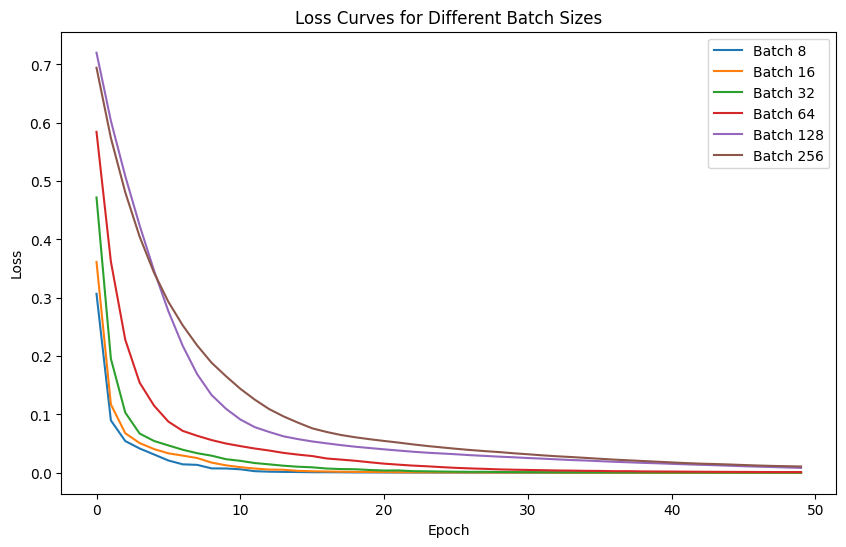

In [15]:
plt.figure(figsize=(10,6))

for batch in batch_sizes:
    plt.plot(histories[batch].history['loss'], label=f'Batch {batch}')

plt.title("Loss Curves for Different Batch Sizes")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

## Optimal Batch Size

The optimal batch size is around 32 or 64.

Reasons:

good balance between training speed and accuracy

stable learning

good generalization

Small batches improve generalization but are slower, while very large batches reduce training time but may hurt performance.

## How Batch Size Affects Convergence

Batch size affects gradient estimation during training.

Small batch sizes:

noisy gradients

better exploration of the loss surface

slower training but often better generalization

Large batch sizes:

smoother gradients

faster computation per epoch

risk of converging to sharp minima with worse generalization.